In [20]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sydr.io.database import DatabaseHandler
from sydr.utils.constants import GPS_L1CA_CODE_SIZE_BITS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Retrieve data from database

In [24]:
receiver_1 = {}
receiver_1['filepath'] = '/mnt/c/Users/vmangr/Documents/Code/sydr/.results/_save/Results_AxC_40MHz_10MHz_8bit/1KV6/REC_GPS_L1CA.db'
receiver_1['database']  = DatabaseHandler(receiver_1['filepath'] , overwrite=False)

In [25]:
receiver_2 = {}
receiver_2['filepath'] = '/mnt/c/Users/vmangr/Documents/Code/sydr/.results/_save/Results_AxC_40MHz_10MHz_8bit/1L12/REC_GPS_L1CA.db'
receiver_2['database']  = DatabaseHandler(receiver_2['filepath'] , overwrite=False)

In [11]:
channelList = receiver_1['database'].fetchTable('channel')
df = pd.DataFrame(channelList)
df

,id,physical_id,system,satellite_id,signal,start_time,stop_time,start_sample
0,0,None,GPS,2,GPS_L1_CA,1.722510e+09,None,0
1,1,None,GPS,3,GPS_L1_CA,1.722510e+09,None,0
2,2,None,GPS,17,GPS_L1_CA,1.722510e+09,None,0
3,3,None,GPS,21,GPS_L1_CA,1.722510e+09,None,0
4,4,None,GPS,32,GPS_L1_CA,1.722510e+09,None,0


In [32]:
channel_id = 1

receiver_1['acquisition'] = receiver_1['database'].fetchAcquisition(channel_id)[0]
receiver_2['acquisition'] = receiver_1['database'].fetchAcquisition(channel_id)[0]


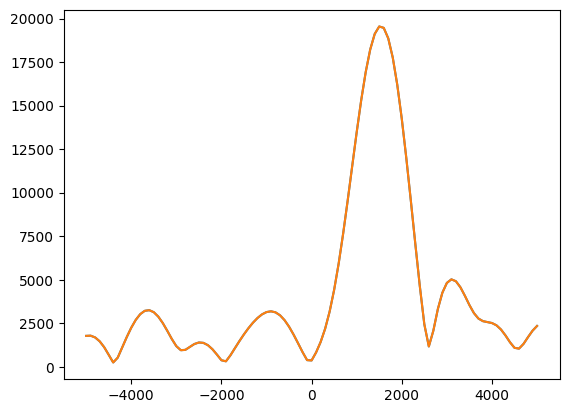

In [33]:
doppler_range = 5000
doppler_steps = 100
frequencyBins = np.arange(-doppler_range, doppler_range+1, doppler_steps)

plt.figure()
plt.plot(frequencyBins, receiver_1['acquisition']["correlation_map"][:, receiver_1['acquisition']["code_idx"]])
plt.plot(frequencyBins, receiver_2['acquisition']["correlation_map"][:, receiver_2['acquisition']["code_idx"]])

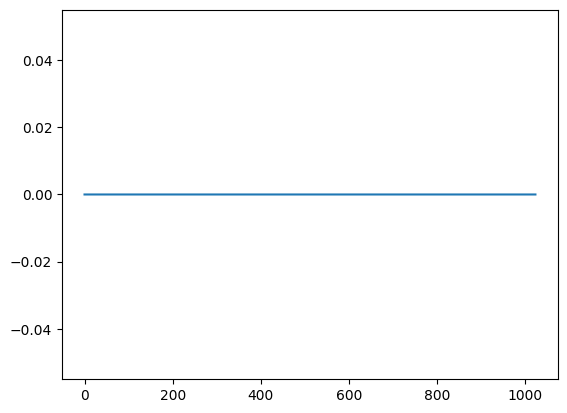

In [37]:
codeBins      = np.linspace(0, GPS_L1CA_CODE_SIZE_BITS, np.size(receiver_1['acquisition']["correlation_map"], axis=1))

plt.figure()
diff = receiver_1['acquisition']["correlation_map"][receiver_1['acquisition']["frequency_idx"], :] - receiver_2['acquisition']["correlation_map"][receiver_2['acquisition']["frequency_idx"], :]
plt.plot(codeBins, diff)
#plt.plot(codeBins, receiver_1['acquisition']["correlation_map"][receiver_1['acquisition']["frequency_idx"], :])
#plt.plot(codeBins, receiver_2['acquisition']["correlation_map"][receiver_2['acquisition']["frequency_idx"], :])